In [77]:
# FinMark Sales Forecasting Model

#This project focuses on forecasting the next 6 months of sales using time series analysis.  
#The goal is to support business decision-making by analyzing historical transaction data and identifying trends.

In [78]:
## Problem Statement

#FinMark aims to improve business planning by predicting future sales performance.  
#This project uses historical transaction data to generate a 6-month sales forecast.

In [79]:
# Import libraries for data handling and visualization
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Import time series models
from statsmodels.tsa.api import SimpleExpSmoothing, ExponentialSmoothing

In [80]:
# Load cleaned datasets (Milestone 1 output)
customers = pd.read_csv(r"C:\Users\0314b\Downloads\customers_cleaned.csv")
products = pd.read_csv(r"C:\Users\0314b\Downloads\products_cleaned.csv")
transactions = pd.read_csv(r"C:\Users\0314b\Downloads\transactions_cleaned.csv")

# Convert transaction date into datetime format
transactions['Transaction_Date'] = pd.to_datetime(transactions['Transaction_Date'])

In [81]:
# Merge transactions with products to include product details
df = transactions.merge(products, on='Product_ID', how='left')

# Merge with customers to include customer-level data
df = df.merge(customers, on='Company_ID', how='left')

# Check combined dataset
df.head()

,Transaction_ID,Company_ID,Product_ID,Quantity,Transaction_Date,Product_Price_x,Total_Cost,Product_Name,Product_Price_y,Company_Name,Company_Profit,Address
0,2,29,19,16,NaT,97930.993380,1428000.0,EcoNomix Modeler,95200.0,Sky Industries 29,61952.0,"Edsa, brgy. 606, makati, philippines!"
1,5,47,3,8,NaT,99575.609634,705600.0,TrendWise Forecaster,100800.0,Green Industries 47,31130.0,"Taft Ave, Barangay 707, Mandaluyong, Philippines"
2,6,80,11,4,2021-07-12,160658.675350,627200.0,OptiFlow Automation,156800.0,Green Partners 80,111227.0,"Commonwealth Ave, Barangay 202, Manila, Philip..."
3,8,21,20,7,NaT,229217.941468,1792000.0,FinSphere Intelligence Suite,224000.0,Dynamic Enterprises 21,75301.5,"Ortigas Ave, Barangay 707, Davao City, Philipp..."
4,10,3,20,6,NaT,238293.851303,1120000.0,FinSphere Intelligence Suite,224000.0,Quantum Associates 3,110664.0,"Roxas Blvd, Barangay 505, Pasig, Philippines"


In [82]:
# Extract monthly period from transaction date
df['Month'] = df['Transaction_Date'].dt.to_period('M')

# Aggregate total sales per month
monthly_sales = df.groupby('Month')['Total_Cost'].sum().reset_index()

# Convert Month to datetime format
monthly_sales['Month'] = monthly_sales['Month'].dt.to_timestamp()

# Set Month as index
monthly_sales.set_index('Month', inplace=True)

# Set frequency to avoid warnings
monthly_sales = monthly_sales.asfreq('MS')

monthly_sales.head()

,Total_Cost
Month,
2020-10-01,6652800.0
2020-11-01,51200800.0
2020-12-01,38348800.0
2021-01-01,51604000.0
2021-02-01,44598400.0


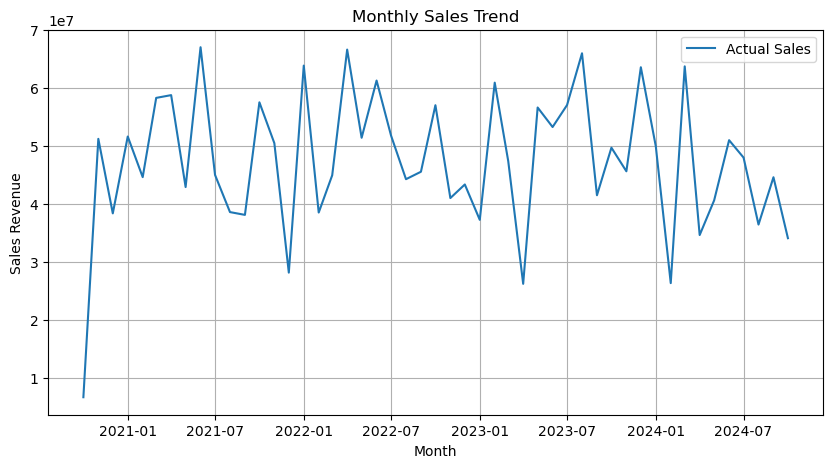

In [83]:
plt.figure(figsize=(10,5))

# Plot actual monthly sales
plt.plot(monthly_sales['Total_Cost'], label='Actual Sales')

plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Sales Revenue")

plt.legend()
plt.grid()
plt.show()

In [84]:
### This graph shows the historical sales trend. It helps identify patterns such as growth, stability, or fluctuations over time.

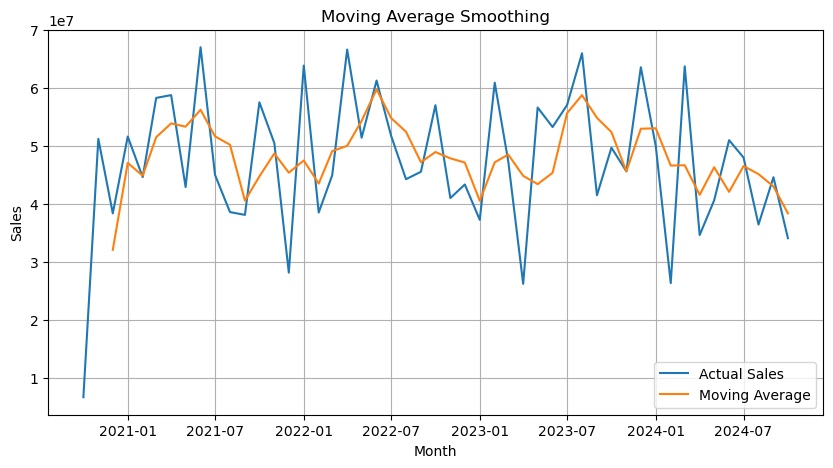

In [85]:
# Apply 3-month moving average to smooth fluctuations
monthly_sales['MA3'] = monthly_sales['Total_Cost'].rolling(window=3).mean()

plt.figure(figsize=(10,5))

plt.plot(monthly_sales['Total_Cost'], label='Actual Sales')
plt.plot(monthly_sales['MA3'], label='Moving Average')

plt.title("Moving Average Smoothing")
plt.xlabel("Month")
plt.ylabel("Sales")

plt.legend()
plt.grid()
plt.show()

In [86]:
## Model Selection Justification

#Simple Exponential Smoothing (SES) was selected because:

#- The dataset shows a relatively smooth trend
#- There is no strong seasonality present
#- The dataset is moderate in size

#ARIMA was not used because:

#- It requires stationarity testing and parameter tuning
#- It is more complex and not necessary for this dataset
#- The goal is to produce interpretable and efficient results

#Therefore, SES and Holt’s model are more appropriate for this analysis.

In [87]:
# Normalize data to avoid convergence issues
scaled_sales = monthly_sales['Total_Cost'] / 100000

# Apply Simple Exponential Smoothing (fixed version)
ses_model = SimpleExpSmoothing(
    scaled_sales
).fit(
    smoothing_level=0.3,   # manually controlled smoothing
    optimized=False        # prevents unstable optimization
)

# Convert back to original scale
monthly_sales['SES'] = ses_model.fittedvalues * 100000

In [88]:
# Apply Holt model on scaled data
holt_model = ExponentialSmoothing(
    scaled_sales,
    trend='add',
    initialization_method='estimated'
).fit(optimized=True)

# Convert back
monthly_sales['Holt_Trend'] = holt_model.fittedvalues * 100000

In [89]:
# Forecast next 6 months
forecast = holt_model.forecast(6)

# Generate future dates
future_dates = pd.date_range(
    start=monthly_sales.index[-1],
    periods=7,
    freq='MS'
)[1:]

# Create forecast dataframe
forecast_df = pd.DataFrame({
    'Month': future_dates,
    'Forecasted_Sales': forecast.values * 100000
})

forecast_df.set_index('Month', inplace=True)

forecast_df

,Forecasted_Sales
Month,
2024-11-01,4.606283e+07
2024-12-01,4.595904e+07
2025-01-01,4.585525e+07
2025-02-01,4.575146e+07
2025-03-01,4.564768e+07
2025-04-01,4.554389e+07


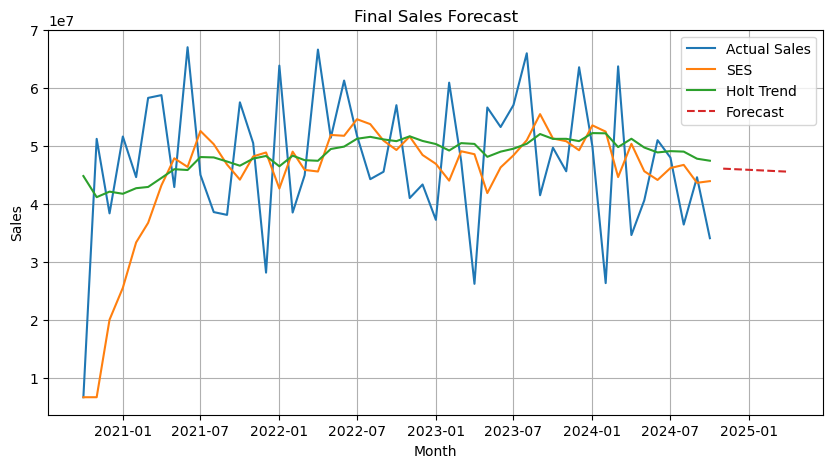

In [90]:
plt.figure(figsize=(10,5))

plt.plot(monthly_sales['Total_Cost'], label='Actual Sales')
plt.plot(monthly_sales['SES'], label='SES')
plt.plot(monthly_sales['Holt_Trend'], label='Holt Trend')
plt.plot(forecast_df['Forecasted_Sales'], label='Forecast', linestyle='--')

plt.title("Final Sales Forecast")
plt.xlabel("Month")
plt.ylabel("Sales")

plt.legend()
plt.grid()
plt.show()

In [91]:
## Model Performance Interpretation

#SES smooths the data but does not capture trends.

#Holt’s model captures trends more effectively, making it more suitable for forecasting.

#Therefore, Holt’s model was used for predicting future sales.

In [92]:
## Forecast Analysis

#The forecast shows a stable trend in sales over the next 6 months.

#This indicates consistent business performance and predictable demand.

In [75]:
## Business Insights

#- Helps improve inventory planning
#- Supports marketing strategies
#- Enables better demand forecasting

In [76]:
## Conclusion

#The project successfully applied time series forecasting to predict future sales.

#Using SES and Holt’s model, we generated reliable forecasts that can support business decisions.